# 06 - Advanced Models (XGBoost)

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
from utils import create_time_split, get_preprocessing_pipeline

df = pd.read_csv('Data/cleaned_sold.csv')
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

max_date = df['CloseDate'].max()
test_start_date = max_date - pd.DateOffset(months=1)

train_df, test_df = create_time_split(df, 'CloseDate', 12, test_start_date, max_date)

X_train = train_df.drop(columns=['ClosePrice'])
y_train = train_df['ClosePrice']

X_test = test_df.drop(columns=['ClosePrice'])
y_test = test_df['ClosePrice']

preprocessor = get_preprocessing_pipeline(X_train)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

Training Window (X=12 months): 2025-05-30 to 2026-05-30 | Rows: 122208
Testing Window (1 month): 2026-05-30 to 2026-06-30


### XGBoost A - Baseline 

In [14]:
import xgboost as xgb

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error


model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='rmse'
)

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))

mdape = np.median(np.abs((np.array(y_test) - np.array(y_pred)) / np.array(y_test)))
print("MdAPE:", mdape)

MSE: 230257944252.34445
R² Score: 0.7091512408452727
MAPE: 0.27832944672922083
MdAPE: 0.19619752155172412


### XGBoost B - Hyperparamter Tuning + Feature Engineering

In [15]:
import geopandas as gpd
from utils import create_time_split, get_preprocessing_pipeline


school_districts = gpd.read_file("california_school_districts.geojson")  
unified_districts = school_districts[school_districts["DistrictType"] == "Unified"].copy()

df = pd.read_csv('Data/cleaned_sold.csv')

properties_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs="EPSG:4326"
)

if properties_gdf.crs != unified_districts.crs:
    properties_gdf = properties_gdf.to_crs(unified_districts.crs)

properties_enriched = gpd.sjoin(
    properties_gdf, 
    unified_districts[['DistrictName', 'geometry']], 
    how="left", 
    predicate="within"  
)

df = properties_enriched.drop(columns=['geometry', 'index_right'])


df['CloseDate'] = pd.to_datetime(df['CloseDate'])

df['BedBathRatio'] = df['BedroomsTotal'] / np.maximum(df['BathroomsTotalInteger'], 1)
df['AgeProperty'] =  (df['CloseDate'].dt.year - df['YearBuilt']).clip(lower=0)

df['BedBathRatio'] = df['BedBathRatio'].replace([np.inf, -np.inf], np.nan).fillna(0)
df['AgeProperty'] = df['AgeProperty'].replace([np.inf, -np.inf], np.nan).fillna(0)

df = df.drop(columns = ["Flooring"]) #too many nulls and weird formatting, had to remove for better performance/less errors

max_date = df['CloseDate'].max()
test_start_date = max_date - pd.DateOffset(months=1)

train_df, test_df = create_time_split(df, 'CloseDate', 12, test_start_date, max_date)

def extract_date_features(dataframe, date_col):
    df_feat = dataframe.copy()
    df_feat[f'{date_col}_year'] = df_feat[date_col].dt.year
    df_feat[f'{date_col}_month'] = df_feat[date_col].dt.month
    df_feat[f'{date_col}_day'] = df_feat[date_col].dt.day
    df_feat[f'{date_col}_dayofweek'] = df_feat[date_col].dt.dayofweek
    df_feat = df_feat.drop(columns=[date_col])
    return df_feat

X_train_raw = train_df.drop(columns=['ClosePrice'])
y_train = train_df['ClosePrice']

X_test_raw = test_df.drop(columns=['ClosePrice'])
y_test = test_df['ClosePrice']

X_train_numeric = extract_date_features(X_train_raw, 'CloseDate')
X_test_numeric = extract_date_features(X_test_raw, 'CloseDate')

preprocessor = get_preprocessing_pipeline(X_train_numeric)
X_train_processed = preprocessor.fit_transform(X_train_numeric)
X_test_processed = preprocessor.transform(X_test_numeric)

Training Window (X=12 months): 2025-05-30 to 2026-05-30 | Rows: 122208
Testing Window (1 month): 2026-05-30 to 2026-06-30


In [16]:
import xgboost as xgb

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error


model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=8,
    eval_metric='rmse'
)

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))

mdape = np.median(np.abs((np.array(y_test) - np.array(y_pred)) / np.array(y_test)))
print("MdAPE:", mdape)

MSE: 95029723645.80826
R² Score: 0.8799638496949772
MAPE: 0.13859749555360645
MdAPE: 0.0983686403508772


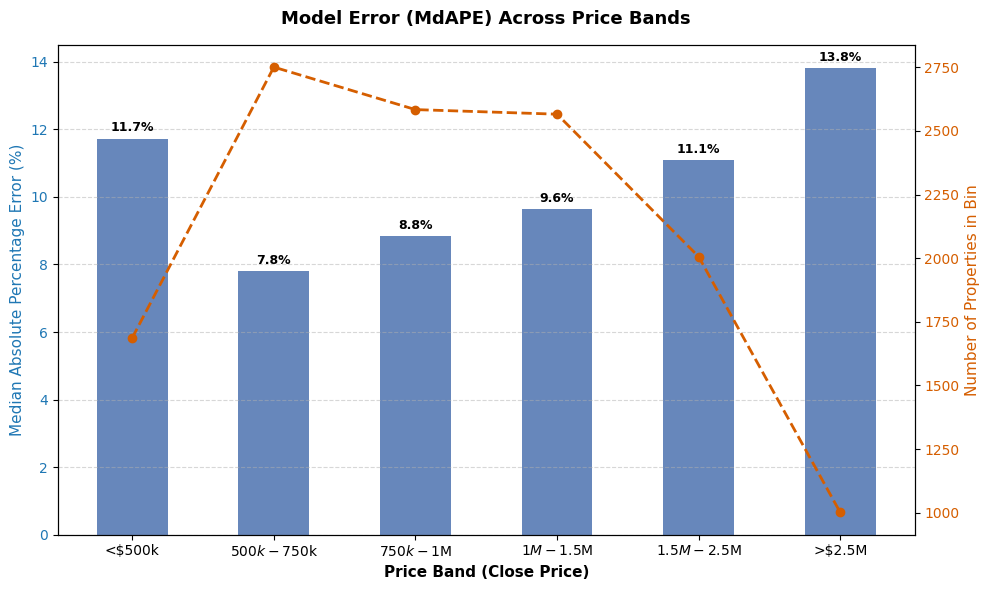

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_df = pd.DataFrame(
    {"Actual": y_test, "Predicted": y_pred, "ClosePrice": y_test}
)

results_df["APE"] = (
    np.abs(results_df["Actual"] - results_df["Predicted"])
    / results_df["Actual"]
) * 100

bins = [0, 500000, 750000, 1000000, 1500000, 2500000, np.inf]
labels = [
    "<$500k",
    "$500k-$750k",
    "$750k-$1M",
    "$1M-$1.5M",
    "$1.5M-$2.5M",
    ">$2.5M",
]

results_df["PriceBand"] = pd.cut(
    results_df["ClosePrice"], bins=bins, labels=labels
)

band_metrics = (
    results_df.groupby("PriceBand", observed=False)
    .agg(
        MdAPE=("APE", "median"),
        MAPE=("APE", "mean"),
        SampleCount=("Actual", "count"),
    )
    .reset_index()
)


fig, ax1 = plt.subplots(figsize=(10, 6))


bars = ax1.bar(
    band_metrics["PriceBand"],
    band_metrics["MdAPE"],
    color="#4C72B0",
    alpha=0.85,
    width=0.5,
)
ax1.set_xlabel("Price Band (Close Price)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Median Absolute Percentage Error (%)", fontsize=11, color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_title("Model Error (MdAPE) Across Price Bands", fontsize=13, fontweight="bold", pad=15)
ax1.grid(axis="y", linestyle="--", alpha=0.5)


for bar in bars:
    height = bar.get_height()
    if not np.isnan(height):
        ax1.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )


ax2 = ax1.twinx()
ax2.plot(
    band_metrics["PriceBand"],
    band_metrics["SampleCount"],
    color="#D55E00",
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Sample Count",
)
ax2.set_ylabel("Number of Properties in Bin", fontsize=11, color="#D55E00")
ax2.tick_params(axis="y", labelcolor="#D55E00")
ax2.grid(False)

plt.tight_layout()
plt.show()

### Comparing Models

In [18]:
compare_table = pd.DataFrame({
    "Model": [

        "Baseline Linear Regression", 
        "Decision Tree (with Feature Engineering)",
        "Random Forest (with Feature Engineering)",
        "Baseline XGBoost",
        "Tuned XGBoost (with Feature Engineering)"
    ],

    "Test R2 Score": [
       0.8249, 
       0.7417,
       0.8315,
       0.7091,
       0.8767
    ]
})

compare_table

,Model,Test R2 Score
0,Baseline Linear Regression,0.8249
1,Decision Tree (with Feature Engineering),0.7417
2,Random Forest (with Feature Engineering),0.8315
3,Baseline XGBoost,0.7091
4,Tuned XGBoost (with Feature Engineering),0.8767


In [19]:
compare_table = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost (with Feature Engineering)",
        "Tuned XGBoost (with School Districts)"
    ],

    "Test R2 Score": [
       0.7091,
       0.8767,
       0.8799
    ]
})

compare_table

,Model,Test R2 Score
0,Baseline XGBoost,0.7091
1,Tuned XGBoost (with Feature Engineering),0.8767
2,Tuned XGBoost (with School Districts),0.8799


Notes: 
- changed ouliters to keep within 1st and 99th percentiles --> increased accuracy by a little bit for XGBoost, decreased/stayed the same for other models
- possible overfitting on training data?
- need to figure out why randomized cv search isn't working